In [1]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Reading the file
from google.colab import files
import io
import pandas as pd

uploaded = files.upload()
data = pd.read_csv(io.StringIO(uploaded['US Wheat Futures Historical Data.csv'].decode('utf-8')))

Saving US Wheat Futures Historical Data.csv to US Wheat Futures Historical Data (1).csv


In [3]:
# Convert 'date' column to datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Rename 'date' column to 'ds'
data = data.rename(columns={'Date': 'ds'})

In [4]:
# Print the first 5 rows of the dataset
print(data.head())

# Get a summary of the dataset
print(data.dtypes)

# Get summary statistics for numerical columns
print(data.describe())

          ds   Price    Open    High     Low     Vol. Change %
0 2022-12-25  792.00  781.25  799.00  765.50   97.48K    2.06%
1 2022-12-18  776.00  755.00  778.00  738.75  165.67K    2.99%
2 2022-12-11  753.50  742.50  772.00  737.60   32.61K    2.62%
3 2022-12-04  734.25  763.25  768.00  723.50  189.69K   -3.52%
4 2022-11-27  761.00  793.25  799.25  755.75  213.75K   -1.87%
ds          datetime64[ns]
Price               object
Open                object
High                object
Low                 object
Vol.                object
Change %            object
dtype: object
                         ds   Price    Open    High     Low    Vol. Change %
count                  1087    1087    1087    1087    1087     567     1087
unique                 1087     910     911     933     906     557      772
top     2022-12-25 00:00:00  516.25  270.00  277.00  395.00  77.29K    1.31%
freq                      1       4       4       4       5       2        6
first   2000-01-02 00:00:00     Na

<ipython-input-4-8aa588a0b9cf>:8: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  print(data.describe())


In [5]:
# Converting "Price", "Open", "High", "Low", "Vol." columns to float datatype
data['Price'] = data['Price'].str.replace(',', '').astype(float)
data['Open'] = data['Open'].str.replace(',', '').astype(float)
data['High'] = data['High'].str.replace(',', '').astype(float)
data['Low'] = data['Low'].str.replace(',', '').astype(float)
data['Vol.'] = data['Vol.'].str.replace('K', '').astype(float) * 1000.
print(data.dtypes)

ds          datetime64[ns]
Price              float64
Open               float64
High               float64
Low                float64
Vol.               float64
Change %            object
dtype: object


In [6]:
# Check for null values in each column
null_counts = data.isnull().sum()

# Print the number of null values in each column
print(null_counts)

ds            0
Price         0
Open          0
High          0
Low           0
Vol.        520
Change %      0
dtype: int64


In [7]:
# fill missing values with mean of the column
data = data.fillna(data.mean())

# Check for null values in each column again
null_counts = data.isnull().sum()

# Print the number of null values in each column
print(null_counts)

ds          0
Price       0
Open        0
High        0
Low         0
Vol.        0
Change %    0
dtype: int64


<ipython-input-7-4e933ffb9d75>:2: FutureWarning: DataFrame.mean and DataFrame.median with numeric_only=None will include datetime64 and datetime64tz columns in a future version.
  data = data.fillna(data.mean())
<ipython-input-7-4e933ffb9d75>:2: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  data = data.fillna(data.mean())


In [8]:
# Drop a column from the dataset
data = data.drop('Change %', axis=1)

# Show the updated dataset
print(data.head())

          ds   Price    Open    High     Low      Vol.
0 2022-12-25  792.00  781.25  799.00  765.50   97480.0
1 2022-12-18  776.00  755.00  778.00  738.75  165670.0
2 2022-12-11  753.50  742.50  772.00  737.60   32610.0
3 2022-12-04  734.25  763.25  768.00  723.50  189690.0
4 2022-11-27  761.00  793.25  799.25  755.75  213750.0


In [9]:
data = data.rename(columns={'Price': 'y'})
print(data.head())

          ds       y    Open    High     Low      Vol.
0 2022-12-25  792.00  781.25  799.00  765.50   97480.0
1 2022-12-18  776.00  755.00  778.00  738.75  165670.0
2 2022-12-11  753.50  742.50  772.00  737.60   32610.0
3 2022-12-04  734.25  763.25  768.00  723.50  189690.0
4 2022-11-27  761.00  793.25  799.25  755.75  213750.0


In [10]:
from prophet import Prophet

In [11]:
# Create a Prophet model
model = Prophet()

In [12]:
# Fit the model to the data
model.fit(data)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpio9ourq_/ajyxm8j6.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpio9ourq_/b43i84to.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=63551', 'data', 'file=/tmp/tmpio9ourq_/ajyxm8j6.json', 'init=/tmp/tmpio9ourq_/b43i84to.json', 'output', 'file=/tmp/tmpio9ourq_/prophet_modelug20jb81/prophet_model-20230607044303.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
04:43:03 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
04:43:04 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [13]:
# Create future dates to make predictions
future_dates = model.make_future_dataframe(periods=7)  # 7 because weekly data
future_dates.tail()

,ds
1089,2022-12-28
1090,2022-12-29
1091,2022-12-30
1092,2022-12-31
1093,2023-01-01


In [14]:
# The predict method will assign each row in future a predicted value which it names 'yhat'.
# in - sample fit
forecast = model.predict(future_dates)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
1089,2022-12-28,881.075467,754.662662,998.806579
1090,2022-12-29,881.377582,760.908654,1003.775976
1091,2022-12-30,881.593069,762.823846,999.381817
1092,2022-12-31,881.725947,757.312173,1005.552707
1093,2023-01-01,881.781403,762.832306,1007.395423


In [15]:
# Make predictions for the future dates
forecast = model.predict(future_dates)

In [16]:
# Access the forecasted values
forecasted_values = forecast[['ds', 'yhat']].tail()

# 'yhat' represents the predicted values of the target variable in the forecasting result.
# 'ds' represents the date column in the datetime format

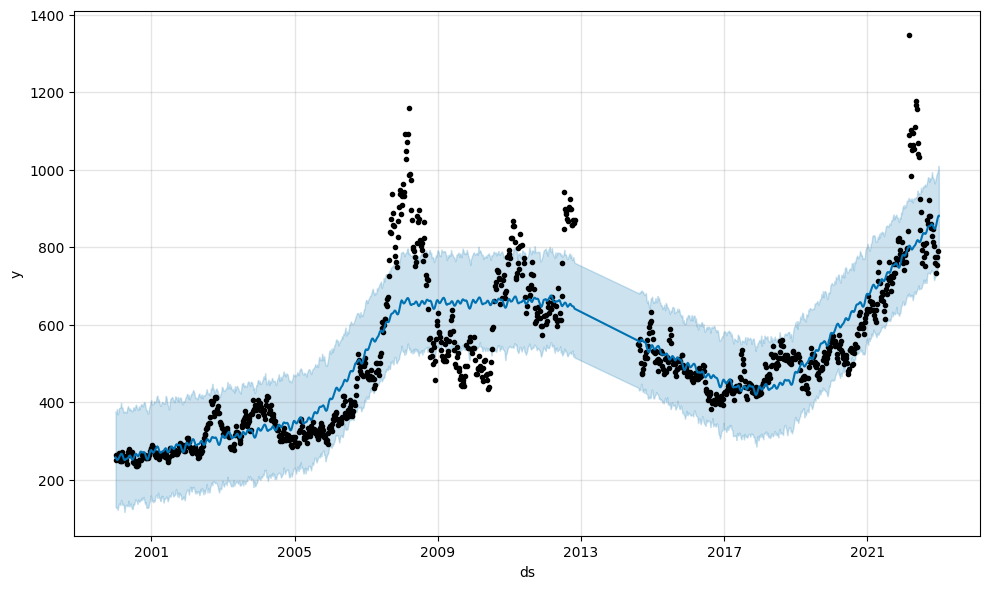

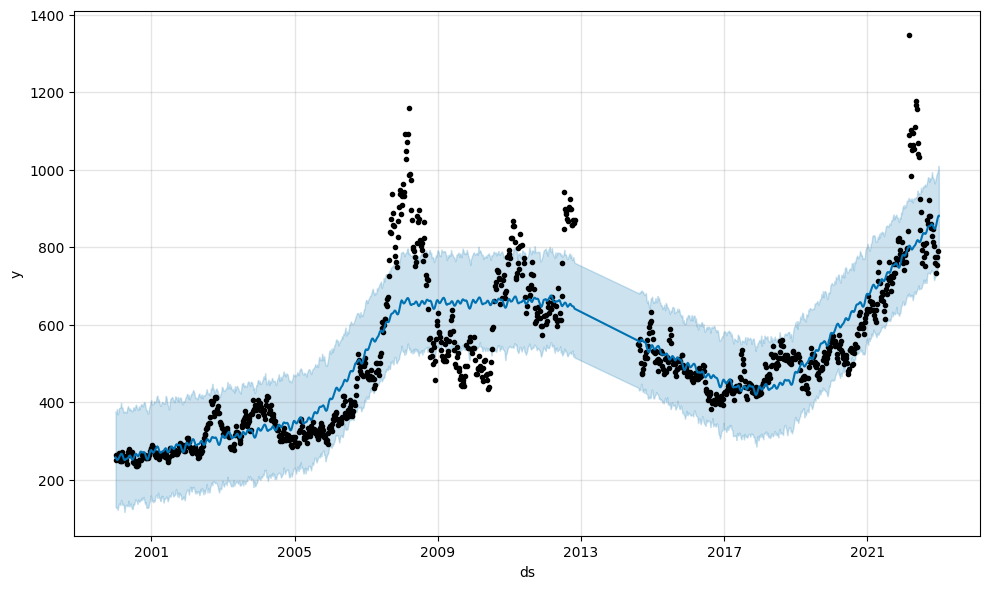

In [17]:
# Plot the forecasted values
model.plot(forecast)

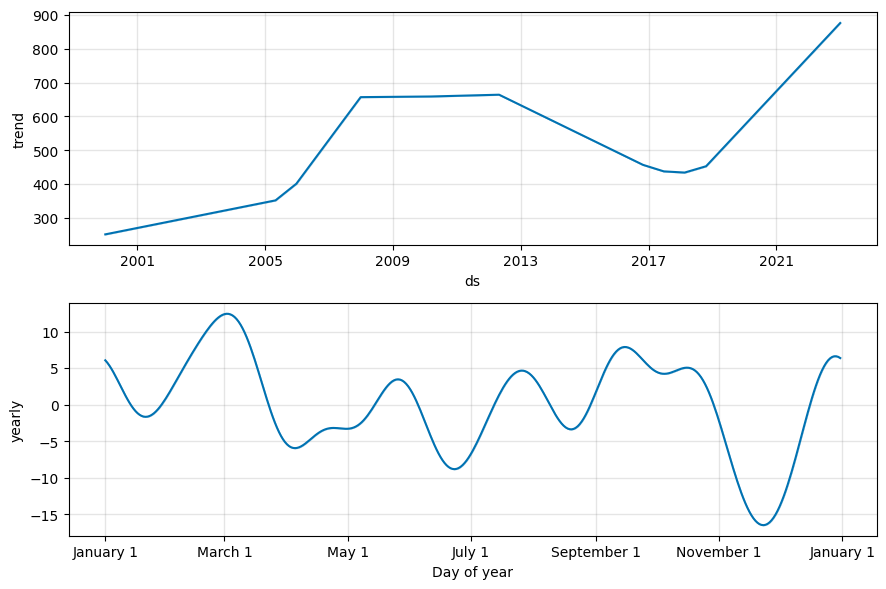

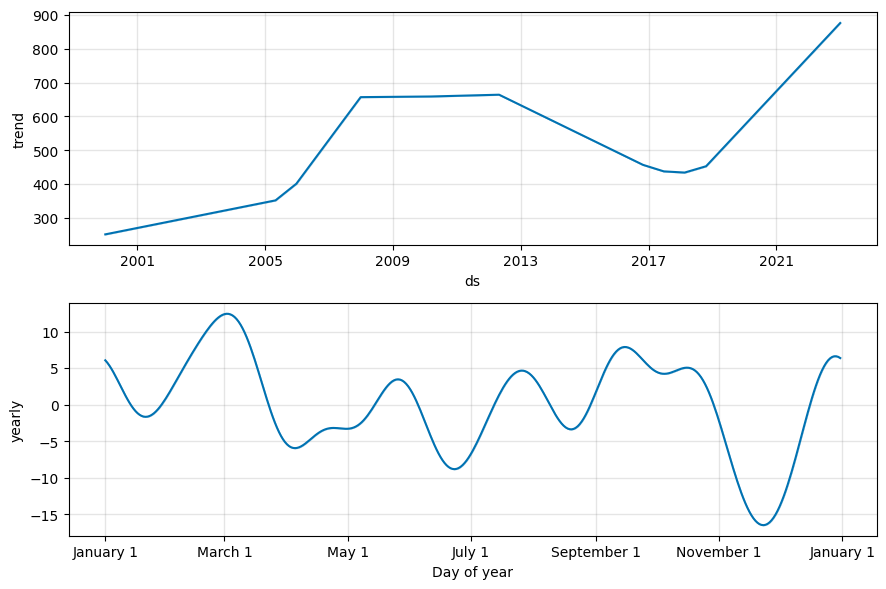

In [18]:
# Access the components of the forecast (trend, seasonality, holidays)
model.plot_components(forecast)

In [19]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

In [20]:
# Extract the actual values from the original dataset
actual_values = data['y'].values

In [21]:
# Extract the predicted values from the forecast dataframe
forecast = model.predict(data)
predicted_values = forecast['yhat'].values

In [22]:
# Calculate RMSE
rmse = mean_squared_error(actual_values, predicted_values, squared=False)
print('RMSE:', rmse)

RMSE: 279.915089320411


In [23]:
from sklearn.metrics import mean_absolute_percentage_error
# Calculate MAPE using scikit-learn
mape_value = mean_absolute_percentage_error(actual_values, predicted_values)
print(mape_value)

0.49602058572765867
